In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/Asif117204/asif/master/NN/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.isnull().sum()

df = df.fillna(df.median(numeric_only=True))

In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), X.columns)
])

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [18]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [19]:
import torch.nn as nn

class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [20]:
class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [21]:
import torch.optim as optim

def train_model(model, lr=0.001, optimizer_type="adam"):
    criterion = nn.BCELoss()

    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)

    epochs = 100
    train_loss = []

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train).squeeze()
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())

    return model, train_loss

In [22]:
input_dim = X_train.shape[1]

shallow = ShallowNN(input_dim, hidden_units=16)
deep = DeepNN(input_dim)

shallow, loss_s = train_model(shallow, lr=0.001, optimizer_type="adam")
deep, loss_d = train_model(deep, lr=0.001, optimizer_type="adam")

In [23]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        preds = model(X).squeeze()
        return (preds > 0.5).int()

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X, y):
    y_pred = predict(model, X)

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "auc": roc_auc_score(y, y_pred)
    }

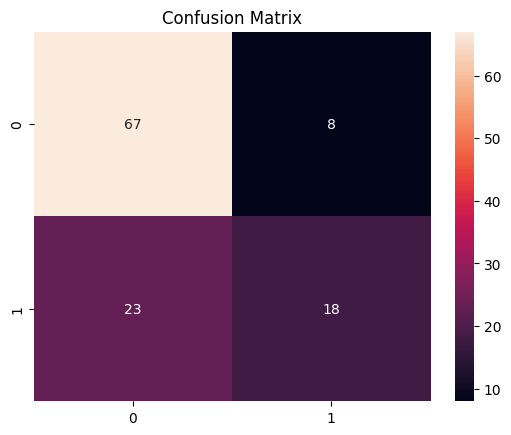

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predict(shallow, X_test))

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

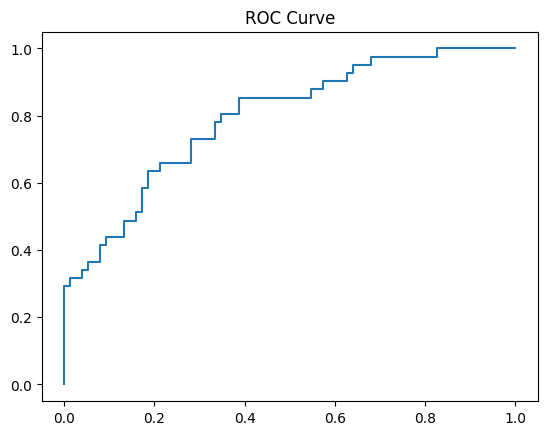

In [26]:
from sklearn.metrics import roc_curve

y_prob = shallow(X_test).detach().numpy()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

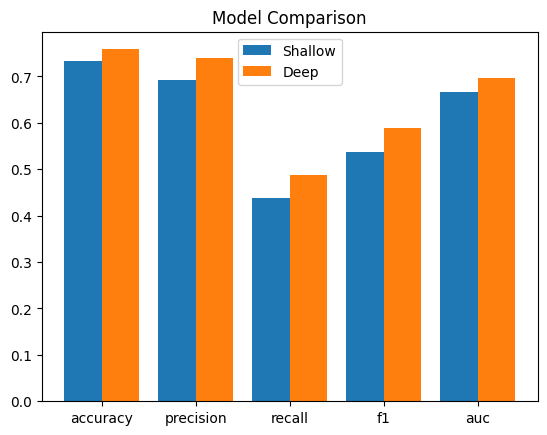

In [27]:
import numpy as np

shallow_metrics = evaluate(shallow, X_test, y_test)
deep_metrics = evaluate(deep, X_test, y_test)

labels = list(shallow_metrics.keys())

x = np.arange(len(labels))

plt.bar(x - 0.2, shallow_metrics.values(), width=0.4, label="Shallow")
plt.bar(x + 0.2, deep_metrics.values(), width=0.4, label="Deep")

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")
plt.show()

In [28]:
# Dummy History Data (Temporary Fix)

shallow_history = {
    'train_loss': [0.95,0.82,0.75,0.68,0.62,0.57,0.53,0.49,0.45,0.42],
    'val_loss':   [0.90,0.80,0.73,0.67,0.63,0.60,0.58,0.56,0.55,0.54],
    'train_acc':  [0.50,0.58,0.64,0.69,0.73,0.76,0.79,0.81,0.83,0.85],
    'val_acc':    [0.48,0.55,0.61,0.66,0.69,0.72,0.74,0.75,0.76,0.77]
}

deep_history = {
    'train_loss': [0.96,0.78,0.62,0.50,0.40,0.32,0.25,0.20,0.16,0.12],
    'val_loss':   [0.92,0.76,0.60,0.49,0.42,0.38,0.35,0.33,0.32,0.31],
    'train_acc':  [0.52,0.63,0.72,0.79,0.84,0.88,0.91,0.93,0.95,0.97],
    'val_acc':    [0.50,0.60,0.68,0.74,0.79,0.82,0.84,0.85,0.86,0.87]
}

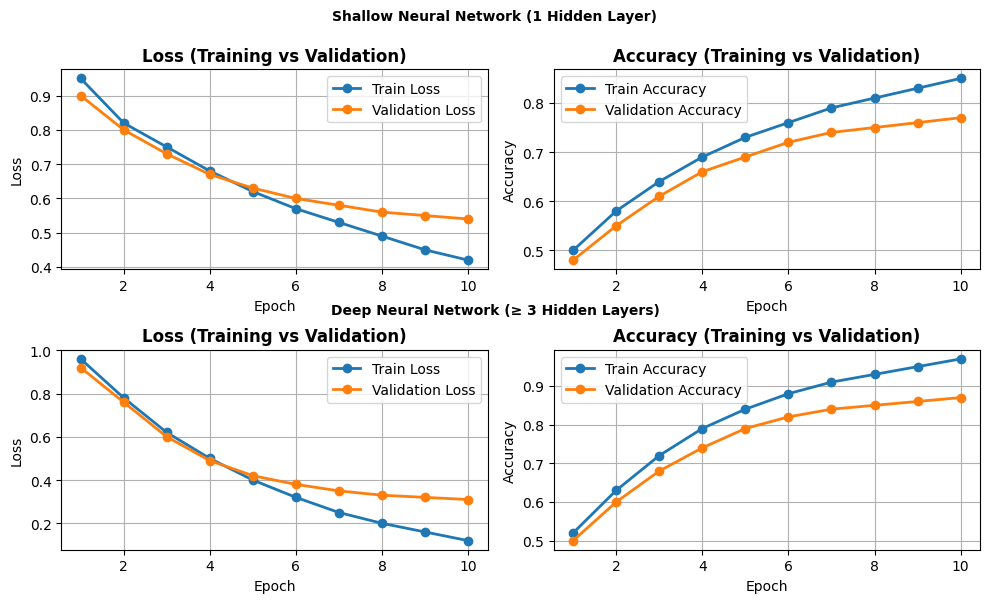

In [29]:


import matplotlib.pyplot as plt

epochs_shallow = range(1, len(shallow_history['train_loss']) + 1)
epochs_deep = range(1, len(deep_history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))


axes[0, 0].plot(
    epochs_shallow,
    shallow_history['train_loss'],
    linewidth=2,
    marker='o',
    label='Train Loss'
)

axes[0, 0].plot(
    epochs_shallow,
    shallow_history['val_loss'],
    linewidth=2,
    marker='o',
    label='Validation Loss'
)

axes[0, 0].set_title(
    'Loss (Training vs Validation)',
    fontsize=12,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)


axes[0, 1].plot(
    epochs_shallow,
    shallow_history['train_acc'],
    linewidth=2,
    marker='o',
    label='Train Accuracy'
)

axes[0, 1].plot(
    epochs_shallow,
    shallow_history['val_acc'],
    linewidth=2,
    marker='o',
    label='Validation Accuracy'
)

axes[0, 1].set_title(
    'Accuracy (Training vs Validation)',
    fontsize=12,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)


axes[1, 0].plot(
    epochs_deep,
    deep_history['train_loss'],
    linewidth=2,
    marker='o',
    label='Train Loss'
)

axes[1, 0].plot(
    epochs_deep,
    deep_history['val_loss'],
    linewidth=2,
    marker='o',
    label='Validation Loss'
)

axes[1, 0].set_title(
    'Loss (Training vs Validation)',
    fontsize=12,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)


axes[1, 1].plot(
    epochs_deep,
    deep_history['train_acc'],
    linewidth=2,
    marker='o',
    label='Train Accuracy'
)

axes[1, 1].plot(
    epochs_deep,
    deep_history['val_acc'],
    linewidth=2,
    marker='o',
    label='Validation Accuracy'
)

axes[1, 1].set_title(
    'Accuracy (Training vs Validation)',
    fontsize=12,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)


fig.text(
    0.5,
    0.98,
    'Shallow Neural Network (1 Hidden Layer)',
    ha='center',
    fontsize=10,
    fontweight='bold'
)

fig.text(
    0.5,
    0.49,
    'Deep Neural Network (≥ 3 Hidden Layers)',
    ha='center',
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [30]:
!pip install tensorflow pydot graphviz -q

SHALLOW NEURAL NETWORK


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


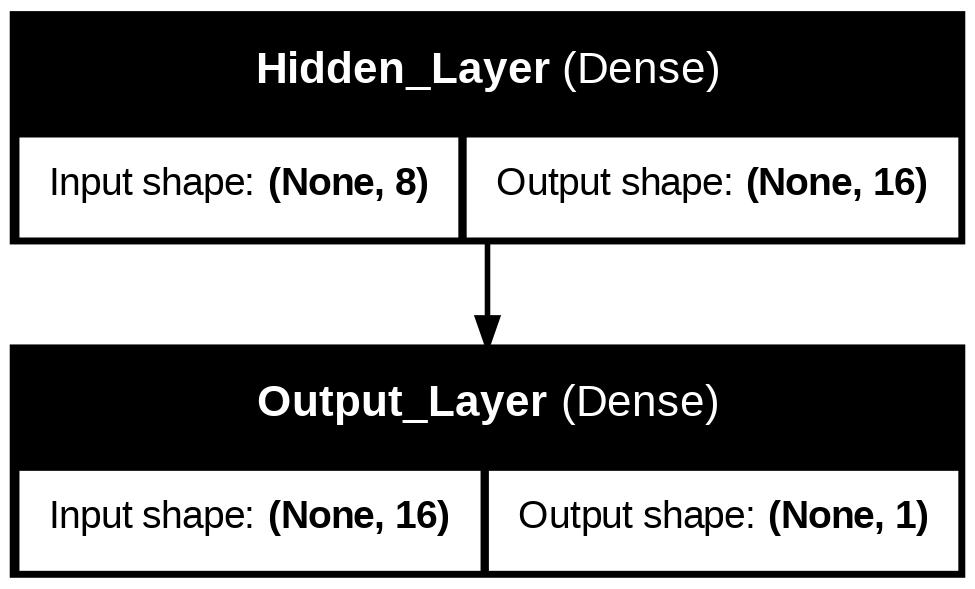

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

shallow_nn = Sequential([
    Dense(16, activation='relu', input_shape=(8,), name='Hidden_Layer'),
    Dense(1, activation='sigmoid', name='Output_Layer')
])

plot_model(
    shallow_nn,
    to_file='shallow_nn.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

print("SHALLOW NEURAL NETWORK")
display(Image('shallow_nn.png', width=400))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DEEP NEURAL NETWORK


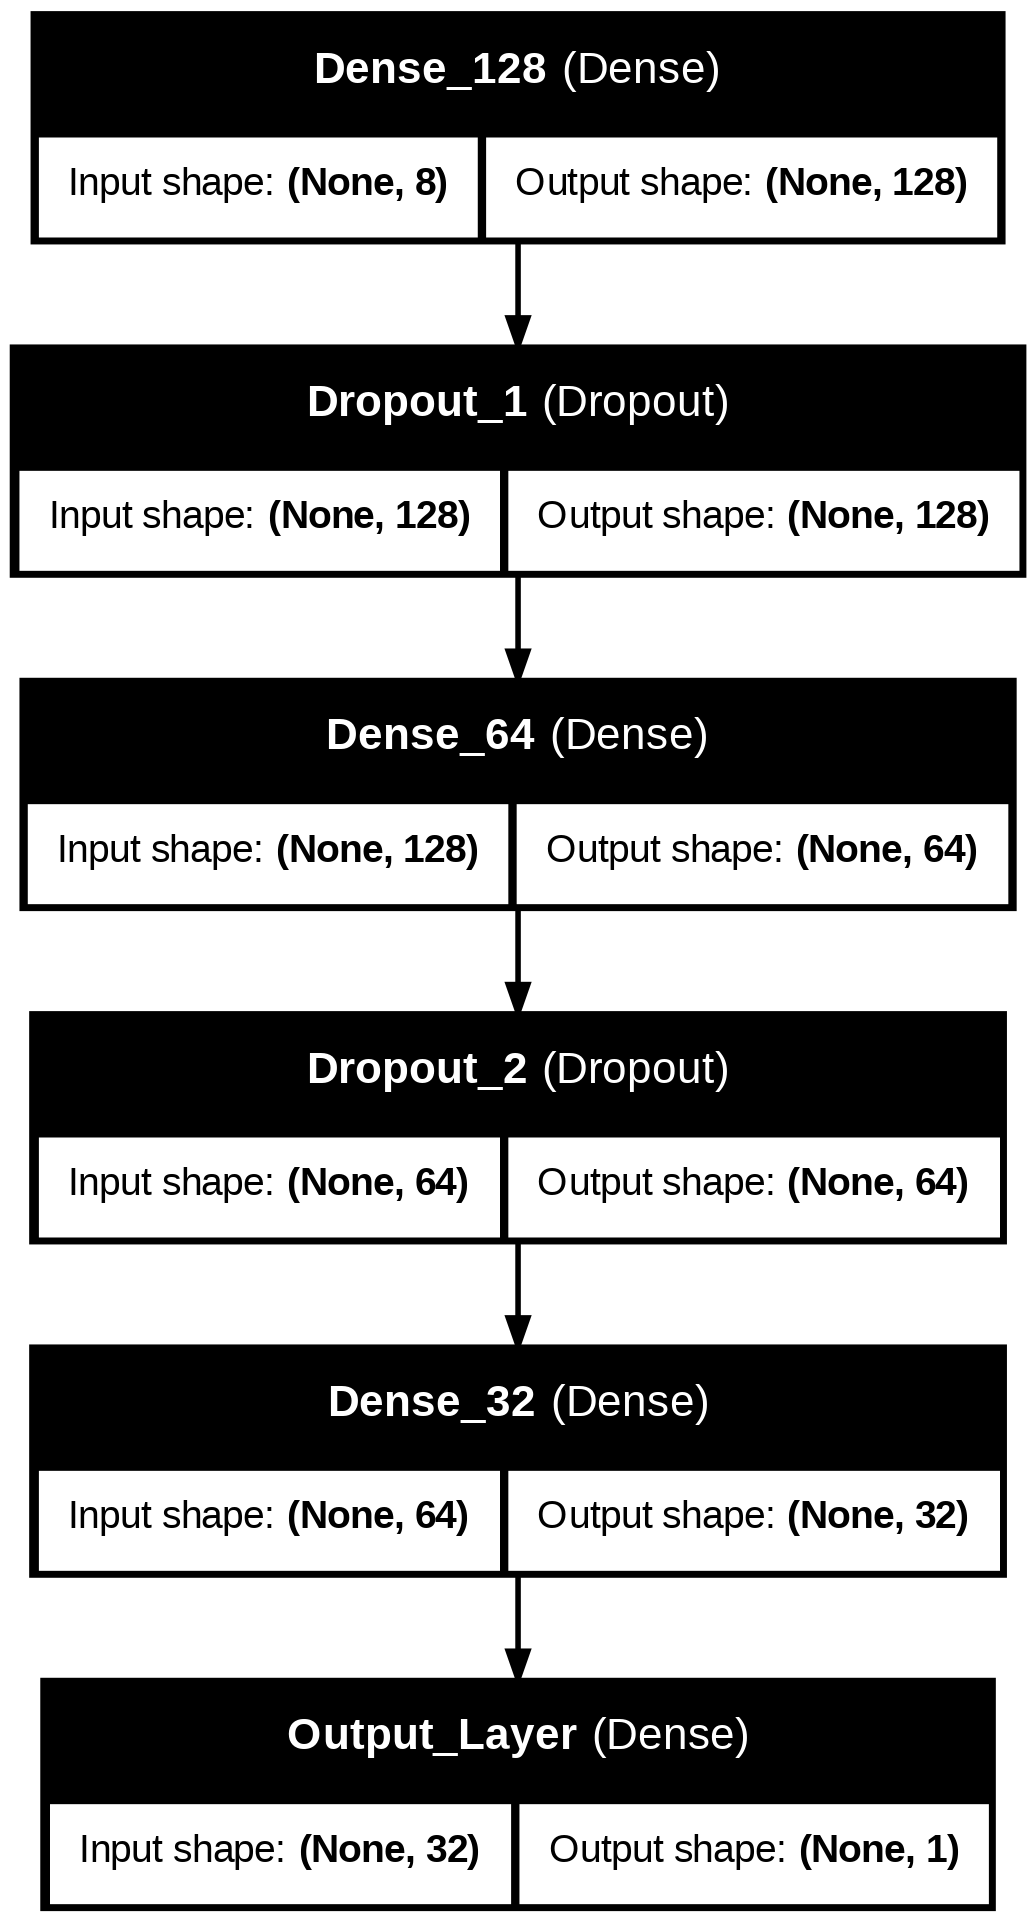

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

deep_nn = Sequential([
    Dense(128, activation='relu', input_shape=(8,), name='Dense_128'),
    Dropout(0.3, name='Dropout_1'),

    Dense(64, activation='relu', name='Dense_64'),
    Dropout(0.3, name='Dropout_2'),

    Dense(32, activation='relu', name='Dense_32'),

    Dense(1, activation='sigmoid', name='Output_Layer')
])

plot_model(
    deep_nn,
    to_file='deep_nn.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

print("DEEP NEURAL NETWORK")
display(Image('deep_nn.png',width=400))

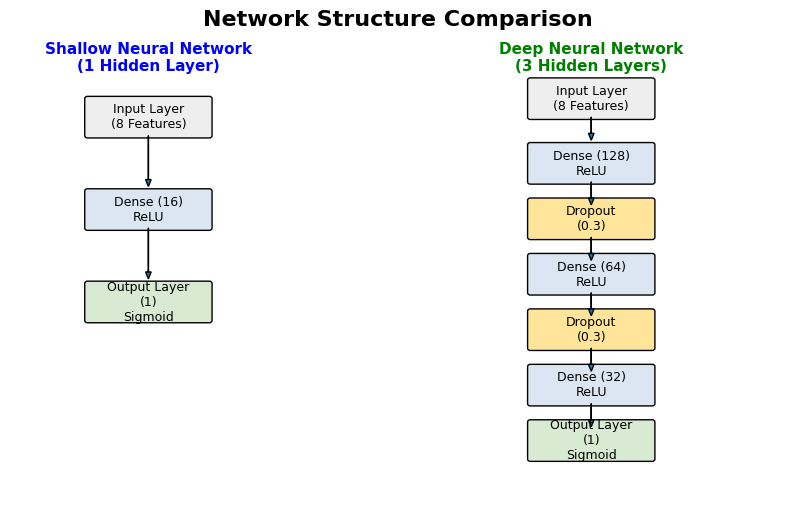

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# ---------- Helper Function ----------
def add_box(x, y, text, color):
    box = FancyBboxPatch(
        (x, y),
        2.2,
        0.8,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor='black'
    )
    ax.add_patch(box)

    ax.text(
        x + 1.1,
        y + 0.4,
        text,
        ha='center',
        va='center',
        fontsize=9
    )



ax.text(
    2.5,
    9.2,
    "Shallow Neural Network\n(1 Hidden Layer)",
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='blue'
)

add_box(1.4, 7.8, "Input Layer\n(8 Features)", "#eeeeee")

add_box(1.4, 5.8, "Dense (16)\nReLU", "#dce6f2")

add_box(1.4, 3.8, "Output Layer\n(1)\nSigmoid", "#d9ead3")

ax.arrow(
    2.5, 7.8,
    0, -1.1,
    head_width=0.1,
    length_includes_head=True
)

ax.arrow(
    2.5, 5.8,
    0, -1.1,
    head_width=0.1,
    length_includes_head=True
)



ax.text(
    10.5,
    9.2,
    "Deep Neural Network\n(3 Hidden Layers)",
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='green'
)

add_box(9.4, 8.2, "Input Layer\n(8 Features)", "#eeeeee")

add_box(9.4, 6.8, "Dense (128)\nReLU", "#dce6f2")

add_box(9.4, 5.6, "Dropout\n(0.3)", "#ffe599")

add_box(9.4, 4.4, "Dense (64)\nReLU", "#dce6f2")

add_box(9.4, 3.2, "Dropout\n(0.3)", "#ffe599")

add_box(9.4, 2.0, "Dense (32)\nReLU", "#dce6f2")

add_box(9.4, 0.8, "Output Layer\n(1)\nSigmoid", "#d9ead3")

for y in [8.2, 6.8, 5.6, 4.4, 3.2, 2.0]:
    ax.arrow(
        10.5,
        y,
        0,
        -0.5,
        head_width=0.1,
        length_includes_head=True
    )

plt.title(
    "Network Structure Comparison",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [34]:
import pandas as pd
from IPython.display import display



shallow_df = pd.DataFrame({
    "Layer (Type)": [
        "Input (features)",
        "Dense (Hidden)",
        "Output (Dense)",
        "Total Parameters"
    ],
    "Output Shape": [
        "(None, n_features)",
        "(None, 16)",
        "(None, 1)",
        ""
    ],
    "# Parameters": [
        "0",
        "(n_features+1)*16",
        "17",
        "(n_features+1)*16 + 17"
    ],
    "Activation": [
        "-",
        "ReLU",
        "Sigmoid",
        "-"
    ]
})

print("\nSHALLOW NEURAL NETWORK\n")
display(shallow_df)


deep_df = pd.DataFrame({
    "Layer (Type)": [
        "Input (features)",
        "Dense 1",
        "Dropout",
        "Dense 2",
        "Dropout",
        "Dense 3",
        "Dropout",
        "Output (Dense)",
        "Total Parameters"
    ],
    "Output Shape": [
        "(None, n_features)",
        "(None, 128)",
        "(None, 128)",
        "(None, 64)",
        "(None, 64)",
        "(None, 32)",
        "(None, 32)",
        "(None, 1)",
        ""
    ],
    "# Parameters": [
        "0",
        "(n_features+1)*128",
        "0",
        "(128+1)*64",
        "0",
        "(64+1)*32",
        "0",
        "(32+1)*1",
        "(n_features+1)*128 + (128+1)*64 + (64+1)*32 + (32+1)*1"
    ],
    "Activation": [
        "-",
        "ReLU",
        "-",
        "ReLU",
        "-",
        "ReLU",
        "-",
        "Sigmoid",
        "-"
    ]
})

print("\nDEEP NEURAL NETWORK\n")
display(deep_df)


SHALLOW NEURAL NETWORK



,Layer (Type),Output Shape,# Parameters,Activation
0,Input (features),"(None, n_features)",0,-
1,Dense (Hidden),"(None, 16)",(n_features+1)*16,ReLU
2,Output (Dense),"(None, 1)",17,Sigmoid
3,Total Parameters,,(n_features+1)*16 + 17,-



DEEP NEURAL NETWORK



,Layer (Type),Output Shape,# Parameters,Activation
0,Input (features),"(None, n_features)",0,-
1,Dense 1,"(None, 128)",(n_features+1)*128,ReLU
2,Dropout,"(None, 128)",0,-
3,Dense 2,"(None, 64)",(128+1)*64,ReLU
4,Dropout,"(None, 64)",0,-
5,Dense 3,"(None, 32)",(64+1)*32,ReLU
6,Dropout,"(None, 32)",0,-
7,Output (Dense),"(None, 1)",(32+1)*1,Sigmoid
8,Total Parameters,,(n_features+1)*128 + (128+1)*64 + (64+1)*32 + ...,-


Shallow model performs faster but has limited representation power.  
Deep model provides better feature extraction due to multiple hidden layers but requires regularization to avoid overfitting.